# Road Damage Severity Index (SI)
This notebook calculates a **Road Severity Index** from real YOLOv8 inference outputs, validates it across sample frames, and visualises the results.

## 1. YOLOv8 Inference Output Structure
When we run `results = model.predict(image)`, YOLOv8 returns a list of `Results` objects one for each input image.

The `Results` object contains different attributes depending on the task. For object detection, the primary attribute is `results.boxes`, which is a specialized `Boxes` object containing all detected bounding boxes. 

Inside `results.boxes`, I can extract the following:
- `boxes.xyxy`: This bounds box coordinates in `[x1, y1, x2, y2]` format.
- `boxes.conf`: This gives the confidence score.
- `boxes.cls`: Basically gives the class ID for the detected object.

## 2. Severity Index Formula

To calculate a Severity Index (SI) that quantifies the overall damage on a road given a single frame, we need to balance the severity of the damage type, the model's confidence, and the physical footprint of the damage relative to the camera view.

**Weights ($W$)**
- Potholes: `1.0` indicates highest sevearity
- Alligator Cracks: `0.8` High sevearity
- Longitudinal Cracks: `0.5` Medium severity
- Transverse Cracks: `0.3` Low severity

**Formula**
The formula for severity index that I am going to be using is:
$$SI = \sum_{i=1}^{n} (W_i \times Confidence_i \times A_{rel, i})$$

Where $A_{rel}$ is the bounding box area relative to the total frame area.

**Severity Grading**

| Grade | SI Range | Description |
|-------|----------|-------------|
| Good | SI < 0.005 | Minimal / no visible damage |
| Fair | 0.005 ≤ SI < 0.02 | Minor cracks, low urgency |
| Poor | 0.02 ≤ SI < 0.05 | Noticeable damage, maintenance needed |
| Critical | SI ≥ 0.05 | Severe damage, immediate attention |

In [1]:
import os, glob, random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

# ── Constants ──
CLASS_NAMES = {0: 'Longitudinal', 1: 'Transverse', 2: 'Alligator', 3: 'Pothole'}
CLASS_WEIGHTS = {0: 0.5, 1: 0.3, 2: 0.8, 3: 1.0}
CLASS_COLORS = {0: '#3498db', 1: '#2ecc71', 2: '#e67e22', 3: '#e74c3c'}

GRADE_THRESHOLDS = [
    (0.005, 'Good'),
    (0.02,  'Fair'),
    (0.05,  'Poor'),
    (float('inf'), 'Critical'),
]

def grade_severity(si):
    """Map a raw SI score to a human-readable grade."""
    for threshold, label in GRADE_THRESHOLDS:
        if si < threshold:
            return label
    return 'Critical'

print('Constants loaded.')
print(f'Classes: {CLASS_NAMES}')
print(f'Weights: {CLASS_WEIGHTS}')

Constants loaded.
Classes: {0: 'Longitudinal', 1: 'Transverse', 2: 'Alligator', 3: 'Pothole'}
Weights: {0: 0.5, 1: 0.3, 2: 0.8, 3: 1.0}


In [2]:
def calculate_severity_index(results, frame_area, weights=None):
    """Calculate the Severity Index from YOLOv8 Results objects.
    
    Args:
        results: List of ultralytics Results objects from model().
        frame_area: Total pixel area of the frame (width * height).
        weights: Optional dict mapping class_id -> severity weight.
    
    Returns:
        Tuple of (severity_index, details_list).
        Each detail dict contains class_id, class_name, confidence,
        bbox_area, relative_area, and weighted_contribution.
    """
    if weights is None:
        weights = CLASS_WEIGHTS
    
    severity_index = 0.0
    details = []
    
    for r in results:
        if r.boxes is None or len(r.boxes) == 0:
            continue
        
        for box in r.boxes:
            class_id = int(box.cls)
            conf = float(box.conf)
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            
            bbox_area = (x2 - x1) * (y2 - y1)
            relative_area = bbox_area / frame_area
            
            w = weights.get(class_id, 0.1)
            contribution = w * conf * relative_area
            severity_index += contribution
            
            details.append({
                'class_id': class_id,
                'class_name': CLASS_NAMES.get(class_id, f'Unknown({class_id})'),
                'confidence': round(conf, 4),
                'bbox': [round(v, 1) for v in [x1, y1, x2, y2]],
                'bbox_area_px': round(bbox_area, 1),
                'relative_area': round(relative_area, 6),
                'weight': w,
                'contribution': round(contribution, 6),
            })
    
    return severity_index, details

print('calculate_severity_index() defined.')

calculate_severity_index() defined.


In [3]:
# ── Load the trained model ──
model_path = '../backend/model/weights/best.pt'
if not os.path.exists(model_path):
    model_path = 'yolov8n.pt'
print(f'Loading model: {model_path}')
model = YOLO(model_path)

# ── Single-frame demo ──
sample_images = sorted(glob.glob('../RDD_SPLIT/val/images/*.jpg'))
if not sample_images:
    sample_images = sorted(glob.glob('../RDD_SPLIT/train/images/*.jpg'))

demo_path = sample_images[0]
img = cv2.imread(demo_path)
h, w = img.shape[:2]
frame_area = w * h

results = model(demo_path, verbose=False)
si, details = calculate_severity_index(results, frame_area)

print(f'\nImage: {os.path.basename(demo_path)}')
print(f'Dimensions: {w}×{h}  |  Frame area: {frame_area:,} px²')
print(f'Detections: {len(details)}')
print(f'\n{"#":<3} {"Class":<15} {"Conf":>6} {"BBox Area":>10} {"Rel Area":>10} {"Weight":>6} {"Contrib":>10}')
print('─' * 68)
for i, d in enumerate(details, 1):
    print(f'{i:<3} {d["class_name"]:<15} {d["confidence"]:>6.4f} {d["bbox_area_px"]:>10.1f} {d["relative_area"]:>10.6f} {d["weight"]:>6.1f} {d["contribution"]:>10.6f}')

print(f'\n{"═" * 68}')
print(f'Severity Index: {si:.5f}  →  Grade: {grade_severity(si)}')

Loading model: ../backend/model/weights/best.pt



Image: China_Drone_000000.jpg
Dimensions: 512×512  |  Frame area: 262,144 px²
Detections: 0

#   Class             Conf  BBox Area   Rel Area Weight    Contrib
────────────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════════════
Severity Index: 0.00000  →  Grade: Good


## 3. Batch Validation
Run inference on a random sample of **30 frames** from the validation set (or training set if val is small) and compute the SI for each. This produces a results table and summary statistics.

In [4]:
# ── Batch validation ──
all_images = sorted(glob.glob('../RDD_SPLIT/val/images/*.jpg'))
if len(all_images) < 10:
    all_images = sorted(glob.glob('../RDD_SPLIT/train/images/*.jpg'))

random.seed(42)
sample_paths = random.sample(all_images, min(30, len(all_images)))

rows = []
for img_path in sample_paths:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    fa = w * h
    
    res = model(img_path, verbose=False)
    si, det = calculate_severity_index(res, fa)
    
    # Per-class detection counts
    class_counts = {CLASS_NAMES[k]: 0 for k in CLASS_NAMES}
    for d in det:
        class_counts[d['class_name']] = class_counts.get(d['class_name'], 0) + 1
    
    row = {
        'image': os.path.basename(img_path),
        'width': w,
        'height': h,
        'detections': len(det),
        **class_counts,
        'SI': round(si, 5),
        'grade': grade_severity(si),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f'Processed {len(df)} frames.\n')
df.sort_values('SI', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df.index += 1
df.index.name = '#'
print(df.to_string())

Processed 30 frames.

                       image  width  height  detections  Longitudinal  Transverse  Alligator  Pothole       SI     grade
#                                                                                                                       
1     China_Drone_001696.jpg    512     512           2             0           0          0        2  0.34271  Critical
2           Japan_012075.jpg    600     600           2             0           0          1        1  0.13138  Critical
3           Japan_009950.jpg    600     600           4             0           1          0        3  0.09164  Critical
4   United_States_003371.jpg    640     640           3             3           0          0        0  0.05678  Critical
5           India_006280.jpg    720     720           1             0           0          1        0  0.05462  Critical
6   United_States_004722.jpg    640     640           6             6           0          0        0  0.04524      Poor
7         

In [5]:
# ── Summary statistics ──
print('Severity Index Statistics')
print('═' * 35)
print(f'  Mean SI:   {df["SI"].mean():.5f}')
print(f'  Median SI: {df["SI"].median():.5f}')
print(f'  Std Dev:   {df["SI"].std():.5f}')
print(f'  Min SI:    {df["SI"].min():.5f}  ({df.loc[df["SI"].idxmin(), "image"]})')
print(f'  Max SI:    {df["SI"].max():.5f}  ({df.loc[df["SI"].idxmax(), "image"]})')

print(f'\nGrade Distribution')
print('═' * 35)
grade_counts = df['grade'].value_counts()
for grade in ['Good', 'Fair', 'Poor', 'Critical']:
    count = grade_counts.get(grade, 0)
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {grade:<10} {count:>3}  ({pct:5.1f}%)  {bar}')

print(f'\nTotal detections across all frames: {df["detections"].sum()}')

Severity Index Statistics
═══════════════════════════════════
  Mean SI:   0.02811
  Median SI: 0.00118
  Std Dev:   0.06713
  Min SI:    0.00000  (Czech_001606.jpg)
  Max SI:    0.34271  (China_Drone_001696.jpg)

Grade Distribution
═══════════════════════════════════
  Good        19  ( 63.3%)  ███████████████████████████████
  Fair         2  (  6.7%)  ███
  Poor         4  ( 13.3%)  ██████
  Critical     5  ( 16.7%)  ████████

Total detections across all frames: 33


## 4. Visualisations

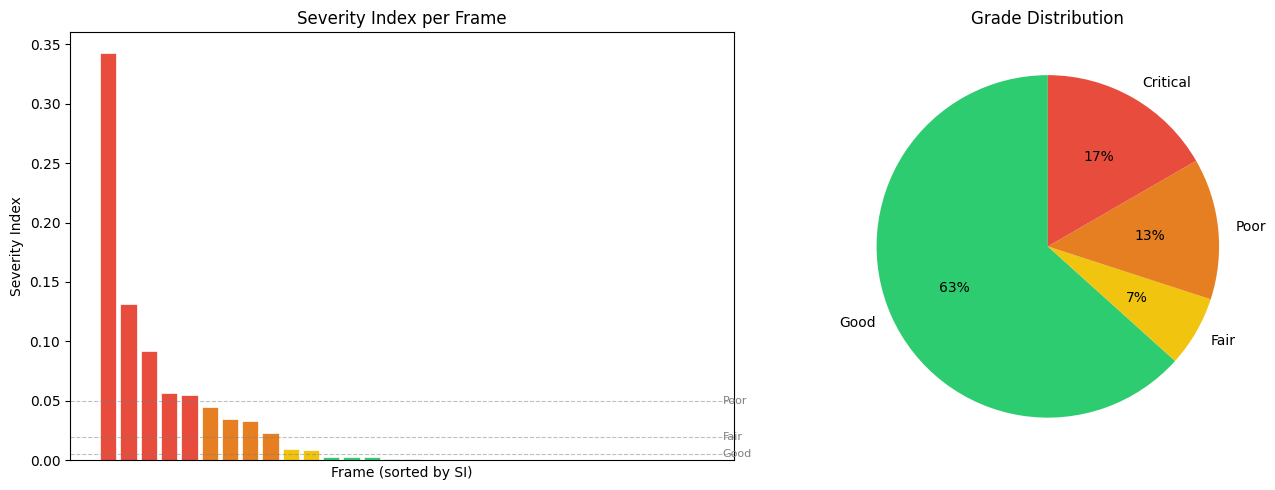

Saved: si_distribution.png


In [6]:
# ── SI Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
grade_colors = {'Good': '#2ecc71', 'Fair': '#f1c40f', 'Poor': '#e67e22', 'Critical': '#e74c3c'}
colors = [grade_colors[g] for g in df['grade']]

ax.bar(range(len(df)), df['SI'].values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Frame (sorted by SI)')
ax.set_ylabel('Severity Index')
ax.set_title('Severity Index per Frame')

# Add grade threshold lines
for thresh, label in GRADE_THRESHOLDS[:-1]:
    ax.axhline(y=thresh, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(len(df) + 0.3, thresh, label, va='center', fontsize=8, color='gray')

ax.set_xticks([])

# Grade pie chart
ax2 = axes[1]
grade_order = ['Good', 'Fair', 'Poor', 'Critical']
counts = [grade_counts.get(g, 0) for g in grade_order]
pie_colors = [grade_colors[g] for g in grade_order]
nonzero = [(g, c, col) for g, c, col in zip(grade_order, counts, pie_colors) if c > 0]

if nonzero:
    labels, vals, cols = zip(*nonzero)
    ax2.pie(vals, labels=labels, colors=cols, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
    ax2.set_title('Grade Distribution')

plt.tight_layout()
plt.savefig('si_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: si_distribution.png')

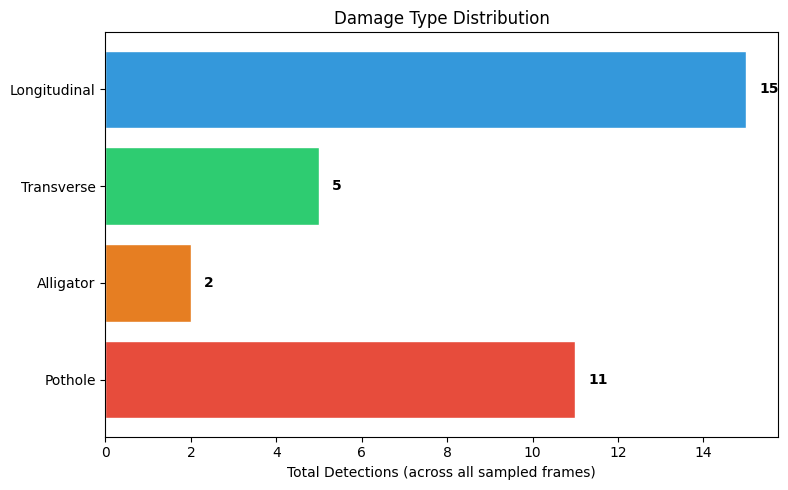

Saved: damage_breakdown.png


In [7]:
# ── Per-class damage breakdown ──
class_cols = list(CLASS_NAMES.values())
class_totals = df[class_cols].sum()

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [CLASS_COLORS[i] for i in range(len(class_cols))]
bars = ax.barh(class_cols, class_totals.values, color=bar_colors, edgecolor='white')

for bar, val in zip(bars, class_totals.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontweight='bold')

ax.set_xlabel('Total Detections (across all sampled frames)')
ax.set_title('Damage Type Distribution')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('damage_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: damage_breakdown.png')

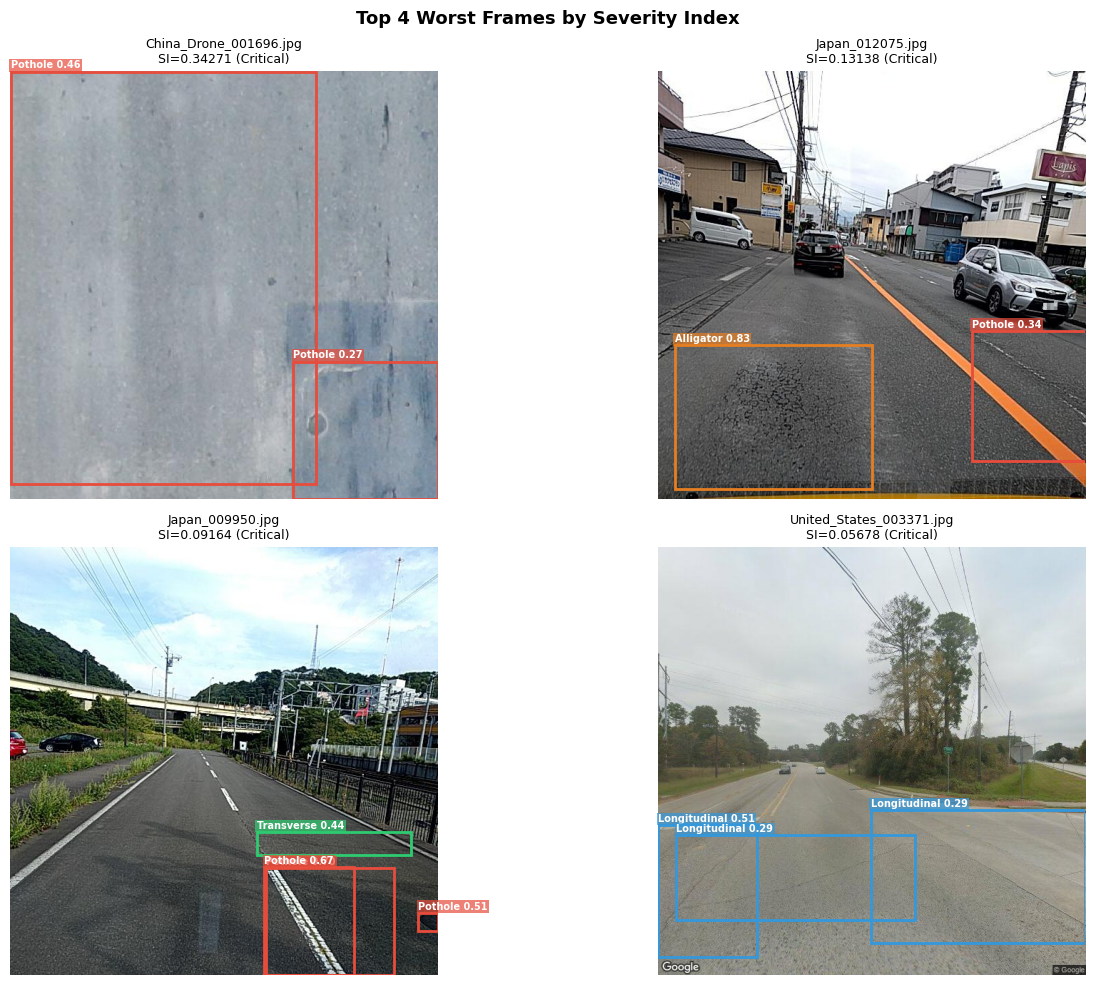

Saved: worst_frames.png


In [8]:
# ── Annotated detections on worst frames ──
worst_frames = df.head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(worst_frames.iterrows()):
    ax = axes[idx]
    img_path = None
    for base in ['../RDD_SPLIT/val/images/', '../RDD_SPLIT/train/images/']:
        candidate = os.path.join(base, row['image'])
        if os.path.exists(candidate):
            img_path = candidate
            break
    
    if img_path is None:
        ax.set_visible(False)
        continue
    
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    fa = w * h
    
    ax.imshow(img_rgb)
    
    res = model(img_path, verbose=False)
    for r in res:
        if r.boxes is None:
            continue
        for box in r.boxes:
            cid = int(box.cls)
            conf = float(box.conf)
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            color = CLASS_COLORS.get(cid, '#ffffff')
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, f'{CLASS_NAMES[cid]} {conf:.2f}',
                    fontsize=7, color='white', fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
    
    ax.set_title(f'{row["image"]}\nSI={row["SI"]:.5f} ({row["grade"]})', fontsize=9)
    ax.axis('off')

plt.suptitle('Top 4 Worst Frames by Severity Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('worst_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: worst_frames.png')